In [1]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
# import visualkeras as vk

from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D,
    Activation,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from sklearn.metrics import confusion_matrix

In [ ]:
# !pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
data = np.load("/content/drive/MyDrive/character recognition/dataset.npz")

In [4]:
train_data = data["train_data"]
test_data = data["test_data"]

train_labels = data["train_labels"]
test_labels = data["test_labels"]

In [5]:
model = Sequential()

model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation="relu"))
model.add(BatchNormalization())

model.add(Conv2D(32, (5, 5), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

model.add(BatchNormalization())
model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(Dense(36, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,556 (3.26 MB)

 Trainable params: 855,364 (3.26 MB)

 Non-trainable params: 192 (768.00 B)

In [6]:
best_loss_checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/character recognition/models/best_loss_model.weights.h5",
    monitor="loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min"
)

best_val_loss_checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/character recognition/models/best_val_loss_model.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min"
)

In [7]:
history = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=10,
    batch_size=200,
    callbacks=[best_loss_checkpoint, best_val_loss_checkpoint]
)

Epoch 1/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.9497 - loss: 0.1761 - val_accuracy: 0.9660 - val_loss: 0.1128
Epoch 2/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9746 - loss: 0.0836 - val_accuracy: 0.9788 - val_loss: 0.0739
Epoch 3/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9806 - loss: 0.0625 - val_accuracy: 0.9763 - val_loss: 0.0797
Epoch 4/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9836 - loss: 0.0505 - val_accuracy: 0.9811 - val_loss: 0.0647
Epoch 5/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9866 - loss: 0.0410 - val_accuracy: 0.9844 - val_loss: 0.0569
Epoch 6/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9881 - loss: 0.0355 - val_accuracy: 0.9855 - val_loss: 0.0537
Epoch 7/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9895 - loss: 0.0310 - val_accuracy: 0.9850 - val_loss: 0.0567
Epoch 8/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9906 - loss:

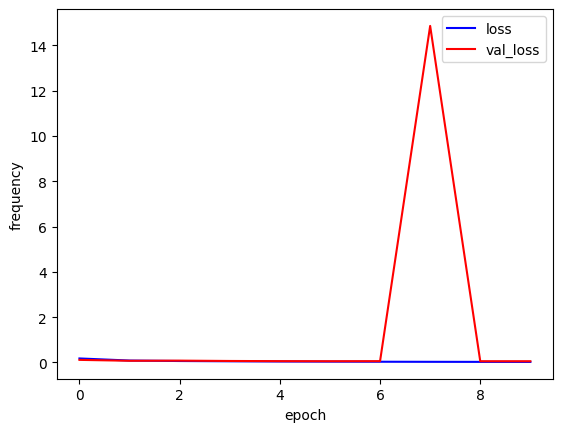

In [8]:
plt.plot(history.history["loss"], 'b', label="loss")
plt.plot(history.history["val_loss"], 'r', label="val_loss")
plt.xlabel("epoch")
plt.ylabel("frequency")
plt.legend()
plt.show()

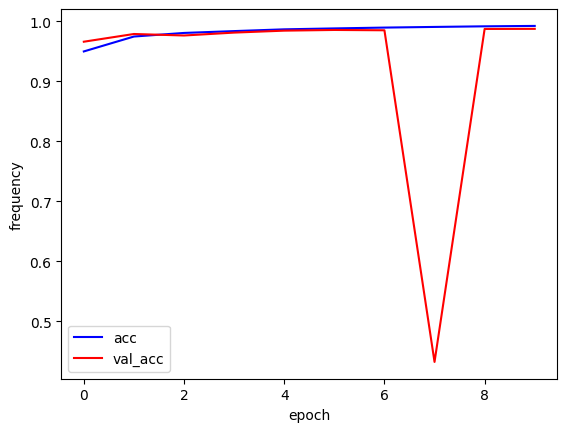

In [9]:
plt.plot(history.history["accuracy"], 'b', label="acc")
plt.plot(history.history["val_accuracy"], 'r', label="val_acc")
plt.xlabel("epoch")
plt.ylabel("frequency")
plt.legend()
plt.show()

In [10]:
model.load_weights("/content/drive/MyDrive/character recognition/models/best_val_loss_model.weights.h5")

In [11]:
loss, acc = model.evaluate(test_data, test_labels)
print(loss, acc)

2766/2766 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9872 - loss: 0.0532
0.05317208915948868 0.9872075915336609


In [12]:
predictions = model.predict(test_data)

2766/2766 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [13]:
confusion = confusion_matrix(
    np.argmax(test_labels, axis=1),
    np.argmax(predictions, axis=1)
)
print(confusion)

[[2759    1    0 ...    0    0    0]
 [   0 1698    0 ...    0    0    0]
 [   0    0 4670 ...    0    0    0]
 ...
 [   0    0    0 ... 1454    1    2]
 [   0   10    0 ...    1 1311    1]
 [   0    0    0 ...    3    3 1349]]


<Axes: xlabel='predicted', ylabel='actual'>

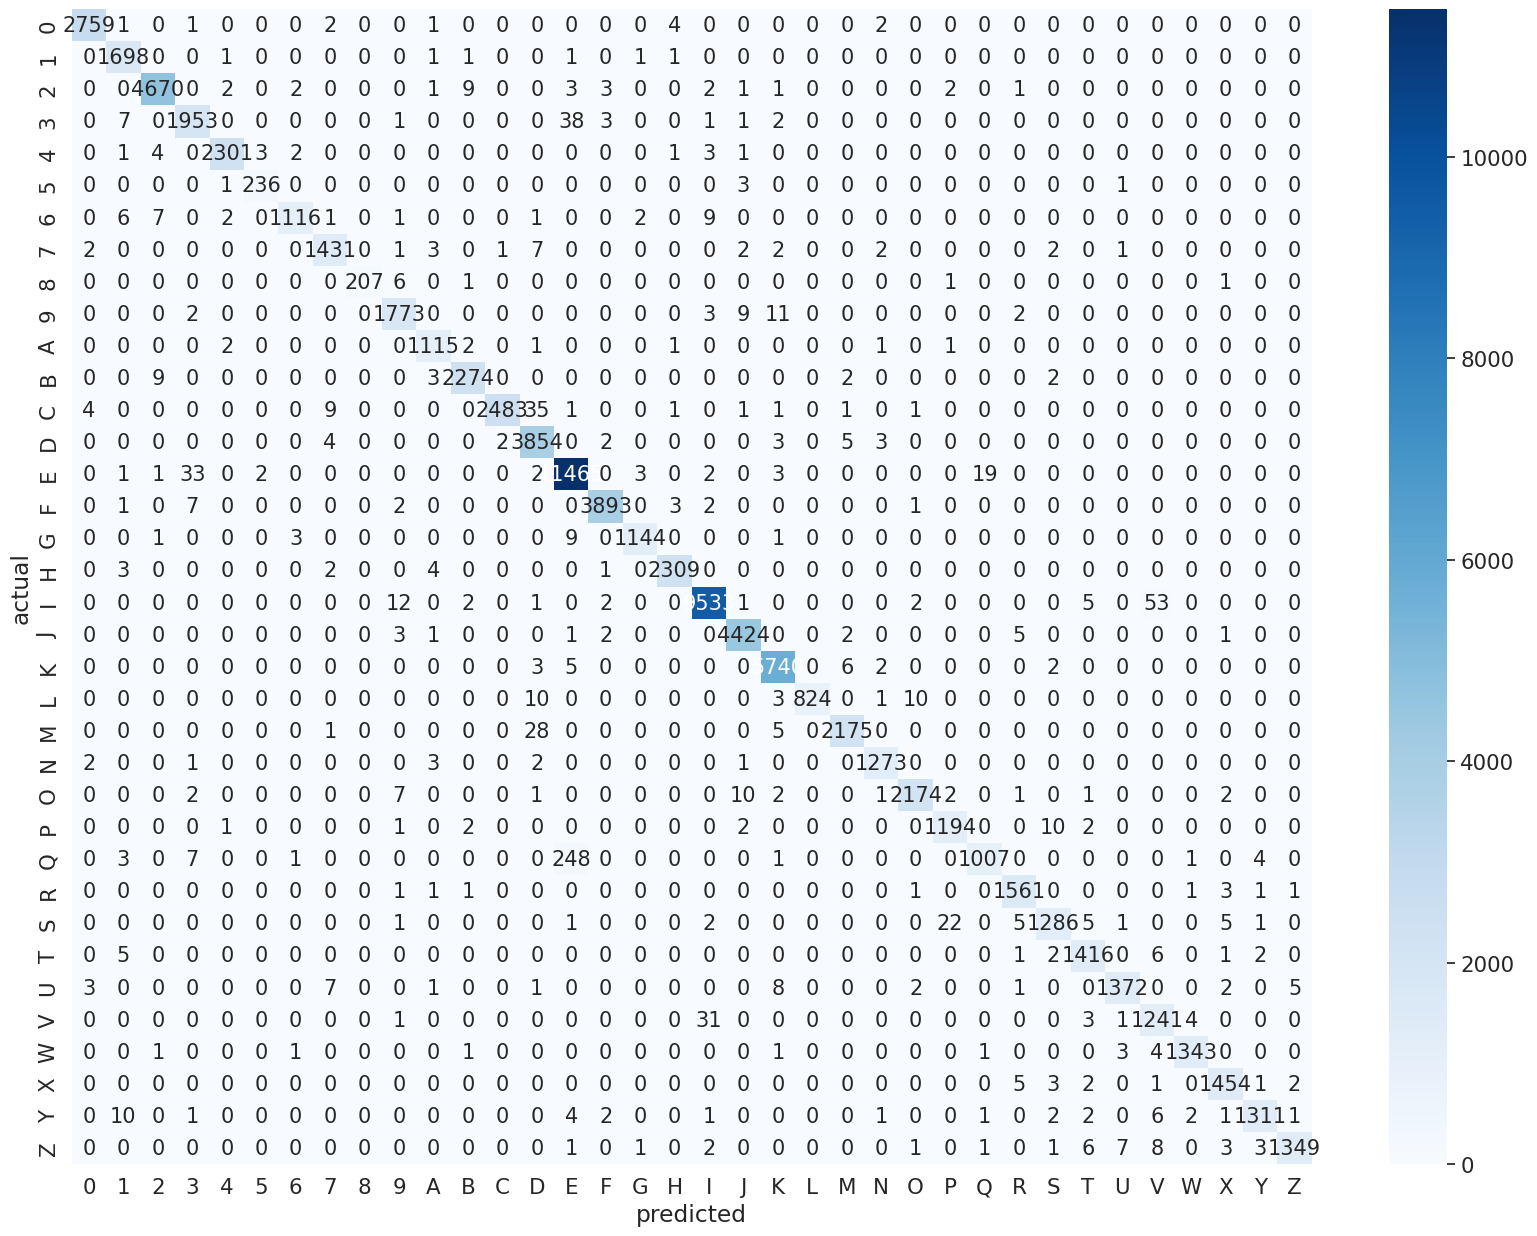

In [14]:
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

df_cm = pd.DataFrame(confusion, columns=np.unique(labels), index = np.unique(labels))
df_cm.index.name = 'actual'
df_cm.columns.name = 'predicted'
plt.figure(figsize = (20,15))
sn.set(font_scale=1.4)
sn.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 15}, fmt="d")

In [15]:
import cv2 as cv
import os

In [16]:
def predict_sample_images(image_folder_path):
  files = os.listdir(image_folder_path)
  for file in files:
    img_path = os.path.join(image_folder_path, file)
    img = cv.imread(img_path)

    # Convert to grayscale
    gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Resize to 28x28
    resized_img = cv.resize(gray_img, (28, 28))
    # Reshape for model input (add batch and channel dimensions)
    input_img = resized_img.reshape(1, 28, 28, 1)
    # Normalize (assuming the model was trained on normalized data)
    input_img = input_img / 255.0

    # Predict
    prediction = model.predict(input_img, verbose=0)
    predicted_class_index = np.argmax(prediction)
    predicted_character = labels[predicted_class_index]

    print(f"Image: {file}, Predicted Character: {predicted_character}")

    # Display the image with its prediction
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) # Display original color image
    plt.title(f"Predicted: {predicted_character}")
    plt.axis('off') # Hide axes
    plt.show()


In [ ]:
sample_images_path = "/content/drive/MyDrive/character recognition/sample images"
predict_sample_images(sample_images_path)